# 05 – Model 3: Gemini 2.5 Flash LLM Pipeline
Zero-shot and few-shot PII extraction via Gemini API.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.utils.io import load_json
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Source Code Walkthrough

The Gemini pipeline has two key source files: prompt construction and the prediction/span-alignment logic.

### prompts.py — Prompt template and few-shot examples

The prompt instructs Gemini to return a JSON array of PII spans with exact character offsets:

In [2]:
# src/models/llm_gemini/prompts.py

SYSTEM_INSTRUCTION = (
    "You are a precise PII extraction engine."
    "Return ONLY a valid JSON array — no prose, no markdown fences."
)

_FEW_SHOT_TEMPLATE = """\
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it appears in the input
  "type"  – one of: PERSON, EMAIL, PHONE, ADDRESS, URL, ID, USERNAME
  "start" – character offset of the first character of the span
  "end"   – character offset one past the last character of the span
...
--- Examples ---
{examples}            # 5 hard-coded diverse few-shot examples
--- End of examples ---

Text:
{text}                # the actual record to process
"""

### predictor.py — API call, response parsing, and span alignment

The predictor sends the prompt to Gemini, parses the JSON response,
anchors entity offsets to real text positions (LLMs miscount characters in long texts),
and converts character spans to BIO token labels:

In [3]:
from utils.io import char_spans_to_bio
from models.llm_gemini.predictor import _validate_spans
import json
import re

# src/models/llm_gemini/predictor.py
def _extract_json(text: str) -> list:
    """Parse JSON array from model response, stripping markdown fences."""
    text = re.sub(r"^```(?:json)?\s*", "", text.strip())
    text = re.sub(r"\s*```$", "", text)
    return json.loads(text)    # fall back to regex [...] search if needed


def _fix_span_offsets(spans: list, text: str) -> list:
    """LLMs miscount character positions in long texts.
    Instead of trusting start/end offsets, find the entity text
    in the source via string search. Use claimed offset as a hint
    to pick the nearest occurrence (handles repeated names)."""
    fixed = []
    for span in spans:
        entity_text = span["text"]
        claimed_start = span.get("start", 0)

        # Find all occurrences of entity text in source
        occurrences = []
        pos = 0
        while True:
            idx = text.find(entity_text, pos)
            if idx == -1: break
            occurrences.append(idx)
            pos = idx + 1

        if not occurrences:
            continue             # entity text not found in source

        # Pick the occurrence closest to Gemini's claimed position
        best = min(occurrences, key=lambda x: abs(x - claimed_start))
        fixed.append({**span, "start": best, "end": best + len(entity_text)})
    return fixed


def predict_record(text, tokens, client, few_shot_k, model_name, char_starts):
    prompt = build_prompt(text, few_shot_k)

    # Call Gemini API
    response = client.models.generate_content(model=model_name, contents=prompt)

    # Parse JSON → validate types → fix offsets → convert to BIO
    spans = _extract_json(response.text)
    spans = _validate_spans(spans, text)
    spans = _fix_span_offsets(spans, text)     # anchor to real positions
    return char_spans_to_bio(tokens, char_starts, spans)

## 1. Prompt preview

In [4]:
from src.models.llm_gemini.prompts import build_prompt

sample_text = (
    'My name is Sarah Connor and you can reach me at sarah.c@example.com'
    'or (555) 867-5309. Visit https://sarah-portfolio.dev for my work.'
)

print('=== ZERO-SHOT PROMPT ===')
print(build_prompt(sample_text, few_shot_k=0), '...')
print('\n=== FEW-SHOT PROMPT (5 examples) ===')
print(build_prompt(sample_text, few_shot_k=5), '...')

=== ZERO-SHOT PROMPT ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it appears in the input
  "type"  – one of: PERSON, EMAIL, PHONE, ADDRESS, URL, ID, USERNAME
  "start" – character offset of the first character of the span
  "end"   – character offset one past the last character of the span

Entity type guide:
PERSON      – full or partial person name (first name, last name, full name)
EMAIL       – email address
PHONE       – phone or fax number
ADDRESS     – street address, city, state, ZIP / postal code, country
URL         – web URL, domain name, IP address
ID          – government ID, SSN, passport, driver's licence, credit-card number, IBAN
USERNAME    – social-media handle, login name, @mention

If no PII is found, return an empty array: []

Text:
My name is Sarah Connor and you can reach me at sarah.c@example.comor (555) 867-5309. Visit https://sarah-portfolio.dev for 

## 2. Few-shot k selection experiment

We tested different values of k (number of few-shot examples in the prompt) on 50 test records
to find the optimal setting before running on the full 500-record sample.

,Precision,Recall,F1,Latency (ms)
k,,,,
0,0.6885,0.5385,0.6043,4142.9
1,0.6667,0.5385,0.5957,4339.6
3,0.8571,0.6923,0.7660,4021.5
5,0.9153,0.6923,0.7883,4112.2
7,0.8939,0.7564,0.8194,4212.2
10,0.9180,0.7179,0.8058,3886.1


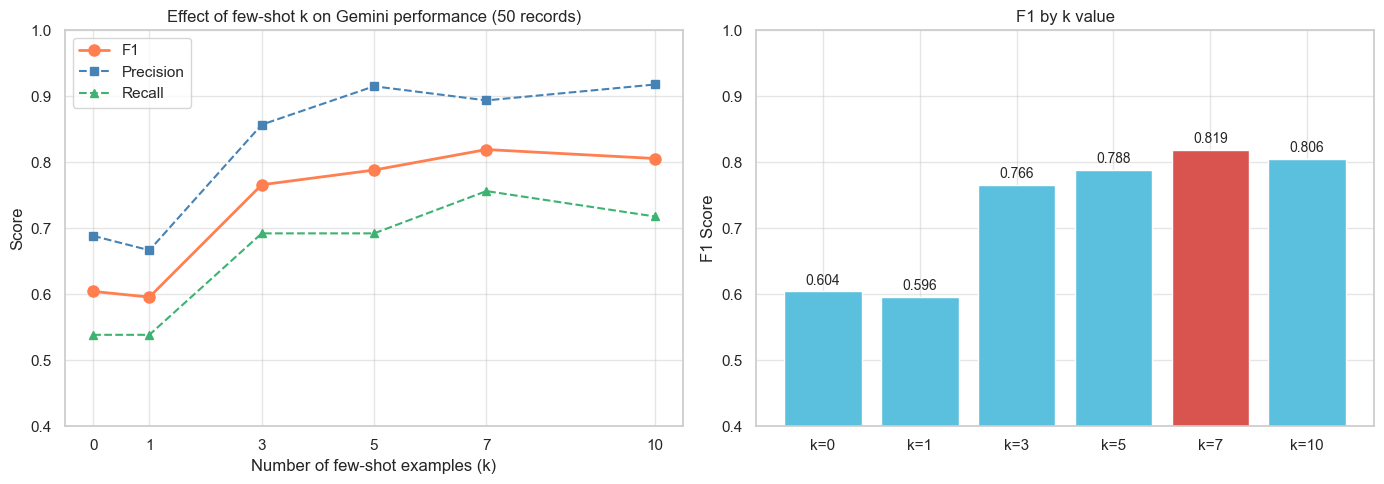


Best k=7 (F1=0.8194) — selected for full 500-record evaluation.


In [5]:
import numpy as np

k_exp = load_json(Path('../outputs/results/llm_k_experiment.json'))
k_vals = k_exp['k_values']
k_results = k_exp['results']

# Summary table
import pandas as pd
rows = []
for k in k_vals:
    m = k_results[str(k)]
    rows.append({'k': k, 'Precision': m['precision'], 'Recall': m['recall'],
                 'F1': m['f1'], 'Latency (ms)': m.get('latency_ms_per_record', 0)})
k_df = pd.DataFrame(rows).set_index('k')
display(k_df)

# Plot F1 vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f1_vals = [k_results[str(k)]['f1'] for k in k_vals]
p_vals = [k_results[str(k)]['precision'] for k in k_vals]
r_vals = [k_results[str(k)]['recall'] for k in k_vals]

axes[0].plot(k_vals, f1_vals, 'o-', color='coral', linewidth=2, markersize=8, label='F1')
axes[0].plot(k_vals, p_vals, 's--', color='steelblue', linewidth=1.5, label='Precision')
axes[0].plot(k_vals, r_vals, '^--', color='mediumseagreen', linewidth=1.5, label='Recall')
axes[0].set_xlabel('Number of few-shot examples (k)')
axes[0].set_ylabel('Score')
axes[0].set_title('Effect of few-shot k on Gemini performance (50 records)')
axes[0].set_xticks(k_vals)
axes[0].legend()
axes[0].set_ylim(0.4, 1.0)

# Bar chart comparing k values
x = np.arange(len(k_vals))
axes[1].bar(x, f1_vals, color=['#d9534f' if f == max(f1_vals) else '#5bc0de' for f in f1_vals],
            edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'k={k}' for k in k_vals])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 by k value')
axes[1].set_ylim(0.4, 1.0)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/results/llm_k_experiment.png', dpi=150)
plt.show()

best_k = k_vals[np.argmax(f1_vals)]
print(f'\nBest k={best_k} (F1={max(f1_vals):.4f}) — selected for full 500-record evaluation.')

## 3. Load pre-computed results (k=7, 500 records)

In [6]:
# Results pre-computed on BGU cluster (~18 min for 500 records)
results_path = Path('../outputs/results/llm_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"Model: {results['model']}  few_shot_k={results['few_shot_k']}")
print(f"Records evaluated: {m.get('records_evaluated', '?')}")
print(f"Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")
print(f"Latency: {m.get('latency_ms_per_record', '?'):.1f} ms / record")

Model: gemini-2.5-flash  few_shot_k=7
Records evaluated: 500
Precision: 0.9278  Recall: 0.7031  F1: 0.8000
Latency: 2078.2 ms / record


## 4. Per-entity F1

,entity,precision,recall,f1,support
1,EMAIL,1.0000,0.8145,0.8978,124
3,PERSON,0.9494,0.7129,0.8143,526
0,ADDRESS,0.8915,0.6845,0.7744,168
6,USERNAME,0.9231,0.5217,0.6667,23
5,URL,0.8571,0.5000,0.6316,24
2,ID,0.3750,1.0000,0.5455,6
4,PHONE,0.8182,0.3600,0.5000,25


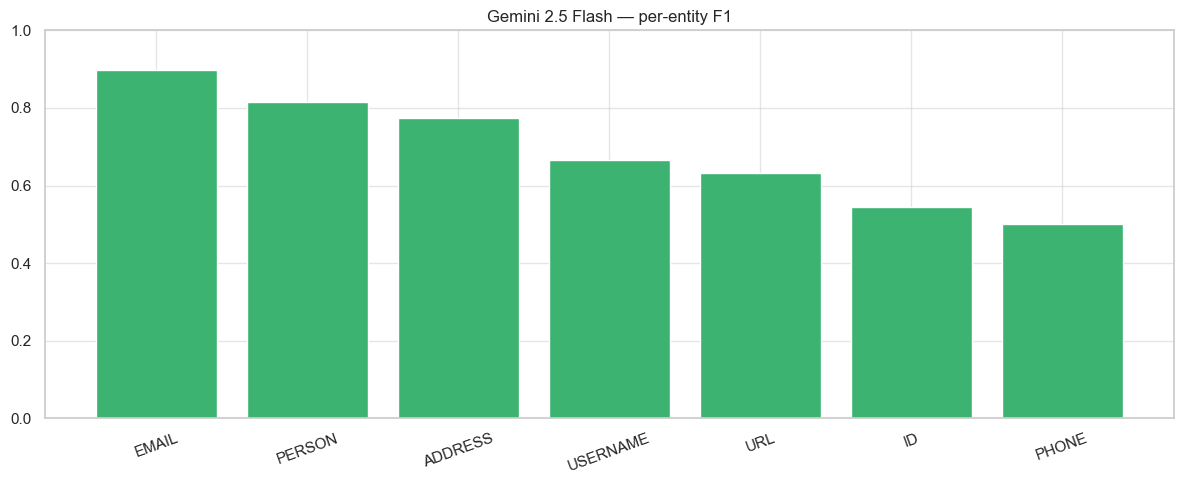

In [7]:
import pandas as pd
per = results['metrics'].get('per_entity', {})
df  = pd.DataFrame([{'entity': k, **v} for k, v in per.items()]).sort_values('f1', ascending=False)
display(df)

fig, ax = plt.subplots()
ax.bar(df['entity'], df['f1'], color='mediumseagreen', edgecolor='white')
ax.set_title('Gemini 2.5 Flash — per-entity F1')
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/llm_per_entity_f1.png', dpi=150)
plt.show()

## 5. How the Gemini pipeline works — code walkthrough

In [8]:
from src.models.llm_gemini.prompts import build_prompt, SYSTEM_INSTRUCTION
from src.models.llm_gemini.predictor import _extract_json

# Show the system instruction
print("=== SYSTEM INSTRUCTION (first 300 chars) ===")
print(SYSTEM_INSTRUCTION[:300], "...\n")

# Show zero-shot vs few-shot prompt
sample_text = (
    'Please contact John Smith at jsmith@company.org or call (212) 555-0184. '
    'Patient record #A-447821 for Maria Gonzalez.'
)
print("=== ZERO-SHOT PROMPT (first 600 chars) ===")
print(build_prompt(sample_text, few_shot_k=0)[:600], "...\n")

print("=== FEW-SHOT PROMPT (first 600 chars) ===")
print(build_prompt(sample_text, few_shot_k=5)[:600], "...\n")

# Show the JSON extraction logic
print("=== RESPONSE PARSING EXAMPLE ===")
fake_response = '```json\n[{"type": "PERSON", "start": 15, "end": 25, "text": "John Smith"}]\n```'
parsed = _extract_json(fake_response)
print(f"Raw response: {fake_response}")
print(f"Parsed spans: {parsed}")

=== SYSTEM INSTRUCTION (first 300 chars) ===
You are a precise PII extraction engine. Return ONLY a valid JSON array — no prose, no markdown fences. ...

=== ZERO-SHOT PROMPT (first 600 chars) ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it appears in the input
  "type"  – one of: PERSON, EMAIL, PHONE, ADDRESS, URL, ID, USERNAME
  "start" – character offset of the first character of the span
  "end"   – character offset one past the last character of the span

Entity type guide:
PERSON      – full or partial person name (first name, last name, full name)
EMAIL       – email address
PHONE       – phone or fax number
ADDRESS     – street address, city, state, ZIP / postal code, c ...

=== FEW-SHOT PROMPT (first 600 chars) ===
Identify all PII spans in the text below and return them as a JSON array.
Each element must have exactly these keys:
  "text"  – the exact substring as it 

## 6. Error Analysis — Where Gemini fails

Despite 82.2% F1, the model makes errors. We categorize them into false negatives (missed PII),
false positives (hallucinated PII), and wrong entity types.

In [9]:
import random
from IPython.display import display, HTML
from src.utils.io import load_jsonl, tokens_to_text

test_records = load_jsonl('../data/processed/test.jsonl')
preds = results['predictions']

# Use the same 500-record sample as the evaluation (seed=42)
rng = random.Random(42)
sample = rng.sample(test_records, min(500, len(test_records)))

# Categorize all errors
false_positives = []
false_negatives = []
wrong_types = []

for rec, pred in zip(sample, preds):
    gt = rec['labels']
    toks = rec['tokens']
    text = tokens_to_text(toks, rec.get('trailing_whitespace'))

    for i in range(min(len(gt), len(pred))):
        if gt[i].startswith('B-') and pred[i] == 'O':
            etype = gt[i][2:]
            j = i + 1
            while j < len(gt) and gt[j] == f'I-{etype}': j += 1
            false_negatives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif pred[i].startswith('B-') and gt[i] == 'O':
            etype = pred[i][2:]
            j = i + 1
            while j < len(pred) and pred[j] == f'I-{etype}': j += 1
            false_positives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif gt[i].startswith('B-') and pred[i].startswith('B-') and gt[i] != pred[i]:
            wrong_types.append({
                'entity': toks[i], 'gt_type': gt[i][2:], 'pred_type': pred[i][2:],
                'text': text[:200], 'source': rec.get('source')
            })

print(f"Error breakdown across {len(sample):,} test records:")
print(f"  False negatives (missed PII):     {len(false_negatives)}")
print(f"  False positives (hallucinated):    {len(false_positives)}")
print(f"  Wrong entity type:                 {len(wrong_types)}")

Error breakdown across 500 test records:
  False negatives (missed PII):     220
  False positives (hallucinated):    29
  Wrong entity type:                 1


In [10]:
# Show one concrete example per error type with highlighted text

def highlight(text, entity, color):
    idx = text.find(entity)
    if idx == -1:
        return f'{text}<br><b style="color:{color}">[{entity}]</b>'
    return (f'{text[:idx]}<b style="background:{color};color:white;'
            f'padding:1px 4px;border-radius:3px">{entity}</b>{text[idx+len(entity):]}')

html = '<h4>False Negative — PII the model missed</h4>'
if false_negatives:
    fn = false_negatives[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{fn["source"]}] '
    html += highlight(fn['text'], fn['entity'], '#e74c3c')
    html += f'<br><i>Missed: <b>{fn["entity"]}</b> (type={fn["type"]})</i></p>'

html += '<h4>False Positive — model detected PII not in ground truth</h4>'
if false_positives:
    fp = false_positives[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{fp["source"]}] '
    html += highlight(fp['text'], fp['entity'], '#3498db')
    html += f'<br><i>Predicted: <b>{fp["entity"]}</b> as {fp["type"]}, ground truth says O</i></p>'

html += '<h4>Wrong Entity Type — correct span, wrong label</h4>'
if wrong_types:
    wt = wrong_types[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{wt["source"]}] '
    html += highlight(wt['text'], wt['entity'], '#e67e22')
    html += f'<br><i><b>{wt["entity"]}</b>: ground truth={wt["gt_type"]}, predicted={wt["pred_type"]}</i></p>'
else:
    html += '<p style="font-size:13px"><i>No wrong-type errors found.</i></p>'

display(HTML(html))